# AFP Checamos: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "afp_checamos"
PLAYER = "AFP Checamos"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, drop_generic_editorial_titles",


SpiderProfile(spider='afp_checamos', display_name='AFP Checamos', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset({'como trabalhamos'}), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix', 'drop_generic_editorial_titles'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
12,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,3982,3982,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

/home/diacrono/Documentos/repositorios/fact-checking-scrape/notebooks/eda_utils.py:194: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["published_at_dt"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")


,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,3982,3981,1,2018-06-21 17:13:00+00:00,2026-03-15 01:01:23+00:00,28,72


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,2f2702e7c2ebff4388446542d6219840210ee079e73cd3a471c7e321e53a9f5d,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/Como-trabalhamos,https://checamos.afp.com/Como-trabalhamos,Como trabalhamos,-,2026-03-15T01:00:06+00:00,Como trabalhamos,NaN,NaN,NaN,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,NaT,2026-03-15 01:00:06+00:00,NaN,16,16,<NA>,checamos.afp.com,1.0
1,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/correcoes,https://checamos.afp.com/correcoes,Correções,-,2026-03-15T01:00:06+00:00,Correções,NaN,NaN,NaN,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,NaT,2026-03-15 01:00:06+00:00,NaN,9,9,<NA>,checamos.afp.com,1.0
2,90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/doc.afp.com.99X47T3,https://checamos.afp.com/doc.afp.com.99X47T3,Posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que Brasil forneceu o material ao Irã,2026-03-04 16:52,2026-03-15T01:00:06+00:00,Brasil forneceu ao Irã ampolas de urânio que desapareceram em 2023,"Estados Unidos e Israel iniciaram em 28 de fevereiro de 2026 ataques ao Irã após falhas na negociação de um acordo nuclear. Desde então, publicações com mai...",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,2026-03-04 16:52:00+00:00,2026-03-15 01:00:06+00:00,248.135,110,66,577,checamos.afp.com,1.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_afp_checamos:c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,factcheck_scrape_afp_checamos,https://checamos.afp.com/correcoes,NaN,pt-br,Correções,None,None,Correções,NaN,correções,correções,correções,correção,NaN,missing,None,[],claim_summary,9,0,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,ClaimReview,[],[],NaN,NaT
1,factcheck_scrape_afp_checamos:90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,factcheck_scrape_afp_checamos,https://checamos.afp.com/doc.afp.com.99X47T3,2026-03-04T16:52:00+00:00,pt-br,Posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que Brasil forneceu o material ao Irã,None,None,Brasil forneceu ao Irã ampolas de urânio que desapareceram em 2023,"Estados Unidos e Israel iniciaram em 28 de fevereiro de 2026 ataques ao Irã após falhas na negociação de um acordo nuclear. Desde então, publicações com mai...",posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,posts usam notícia sumiço 16 g urânio alegar falsamente brasil forneceu material irã brasil forneceu irã ampolas urânio desapareceram 2023 estados unidos is...,post usar notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil fornecer o material a o irã brasil fornecer a o irã ampola de urânio que ...,Falso,false,None,"[{'text': 'brasil', 'label': 'LOC', 'start_char': 77, 'end_char': 83}, {'text': 'irã brasil', 'label': 'ORG', 'start_char': 107, 'end_char': 117}, {'text': ...",claim_summary,755,9,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,ClaimReview,[],[],1,2026-03-04 16:52:00+00:00
2,factcheck_scrape_afp_checamos:fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,factcheck_scrape_afp_checamos,https://checamos.afp.com/,2026-03-15T01:00:06+00:00,pt-br,Checamos,None,None,Checamos,"O fact-checking da AFP é um departamento da Agence France-Presse (AFP), uma agência de notícias multilíngue e multicultural cuja missão é fornecer uma cober...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...",checamos fact-checking afp departamento agence france-presse afp agência notícias multilíngue multicultural missão fornecer cobertura precisa equilibrada im...,checar o fact-checking de o afp ser um departamento de o agence france-presse afp um agência de notícia multilíngue e multicultural cujo missão ser fornecer...,NaN,missing,None,"[{'text': 'afp', 'label': 'ORG', 'start_char': 28, 'end_char': 31}, {'text': 'afp', 'label': 'ORG', 'start_char': 75, 'end_char': 78}]",claim_summary,275,2,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NaN,[],[],NaN,2026-03-15 01:00:06+00:00


## Text-length histograms by label

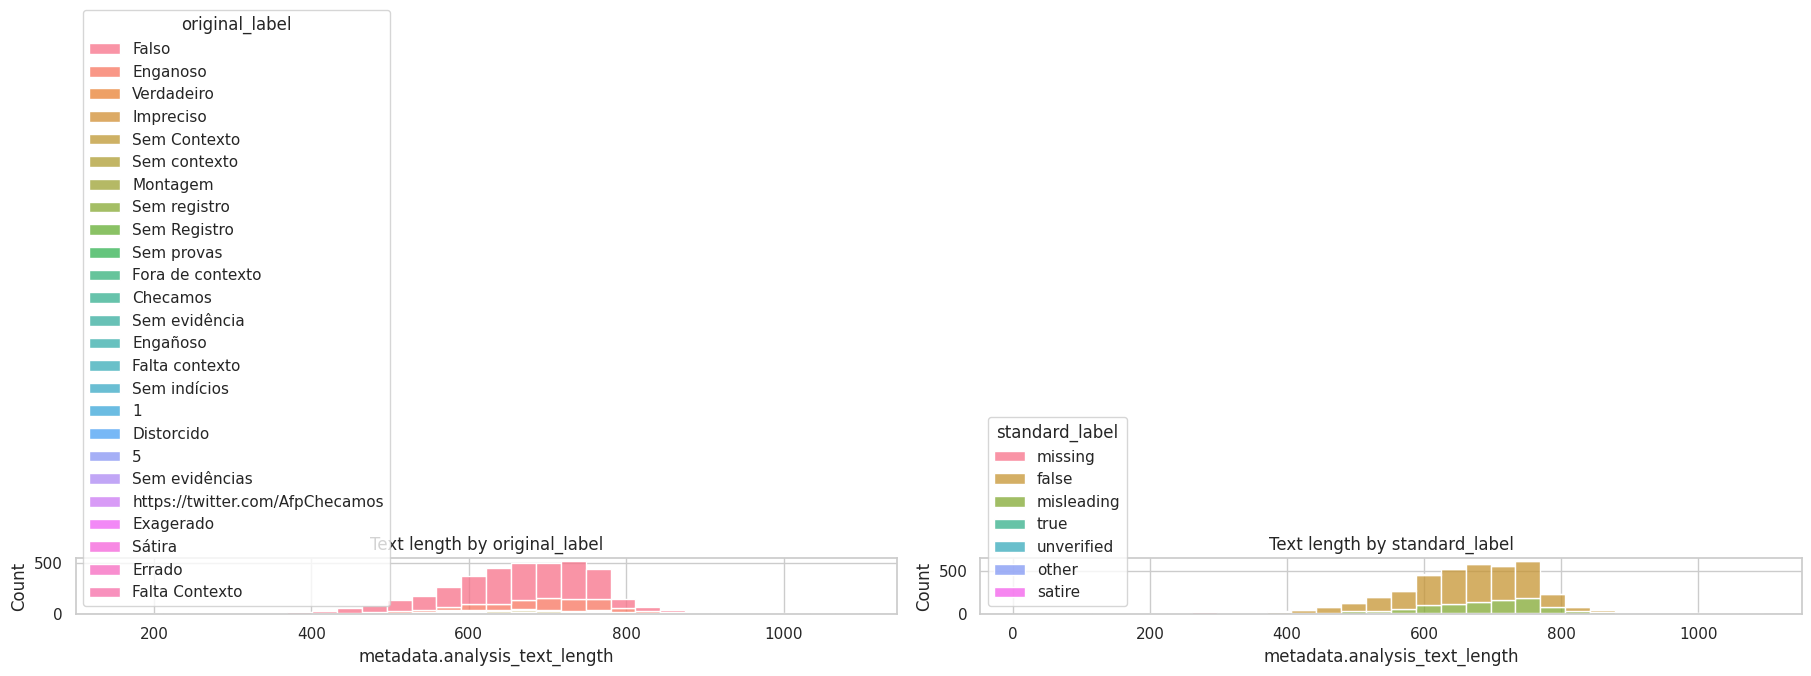

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,None,3981


,topic,count


,tag,count


/tmp/ipykernel_2044877/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
70,2024-04-01,55
71,2024-05-01,55
72,2024-06-01,50
73,2024-07-01,52
74,2024-08-01,58
75,2024-09-01,53
76,2024-10-01,65
77,2024-11-01,48
78,2024-12-01,47
79,2025-01-01,54


,field,missing_count
0,title,0
1,claim,0
2,summary,19
3,verdict,73
4,rating,73
5,published_at,0


,source_record_id,title,published_at
0,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,Correções,NaN
3,5c5227d82c7fba1768bdbbd3b8467d2c69cc7b676816d2c695969bd393cbaf31,Conheça a equipe,NaN
4,71e9b2e6708db8ba3c52fd966335d595ae9fc8145dd1b14726f05b79adbef39d,Normas éticas e editoriais da AFP,NaN
5,09e860948283ef888c991cb2a9308f9704ef0aa7550bbc6c2e149444219bc70b,Contato,NaN
6,5c1ec42f04b8c92120489dda40333b1e5000d62ac0b730ebd6b8c37811ba193e,Configurações de cookies,NaN
7,49d25d41d14a1128d28e57ba7ea6b07239746786da2cc79e67a4eec53f517a5e,Manual de estilo de verificação digital da AFP,NaN
8,298c5a38ca21b3475e066d8779e2ebc88cf869ca7c232f9e62d055a44464a235,Sobre a AFP,NaN
211,8c1a16b2ba43d564f1a6a1213a46c592295a91f4cfac737f5d995a09f6b04dd0,Sequência de venezuelanos em embarcações circula como se fosse uma recepção a navio dos Estados Unidos,NaN
762,0904976f0857a012521889ac6b01ea8157e777ccec2a404c7c7e6063a8bbe171,Participação de Musk em um podcast é falsamente dublada com menção a insulto de Janja no G20 Social,NaN
824,3a0610691aaa8d576d29588f420e1062ed43a2783ed14fdf4ee5a9253f67ae99,Imagens de um avião pousando em Beirute em meio a um bombardeio foram geradas com IA,NaN


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,2f2702e7c2ebff4388446542d6219840210ee079e73cd3a471c7e321e53a9f5d,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/Como-trabalhamos,https://checamos.afp.com/Como-trabalhamos,Como trabalhamos,-,2026-03-15T01:00:06+00:00,Como trabalhamos,NaN,NaN,NaN,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,NaT,2026-03-15 01:00:06+00:00,NaN,16,16,<NA>,checamos.afp.com,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/correcoes,https://checamos.afp.com/correcoes,Correções,-,2026-03-15T01:00:06+00:00,Correções,NaN,NaN,NaN,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,NaT,2026-03-15 01:00:06+00:00,NaN,9,9,<NA>,checamos.afp.com,1.0,Correções,Correções,NaN,correções,NaN,missing,NaN
2,90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/doc.afp.com.99X47T3,https://checamos.afp.com/doc.afp.com.99X47T3,Posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que Brasil forneceu o material ao Irã,2026-03-04 16:52,2026-03-15T01:00:06+00:00,Brasil forneceu ao Irã ampolas de urânio que desapareceram em 2023,"Estados Unidos e Israel iniciaram em 28 de fevereiro de 2026 ataques ao Irã após falhas na negociação de um acordo nuclear. Desde então, publicações com mai...",Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,2026-03-04 16:52:00+00:00,2026-03-15 01:00:06+00:00,248.135000,110,66,577,checamos.afp.com,1.0,Posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que Brasil forneceu o material ao Irã,Brasil forneceu ao Irã ampolas de urânio que desapareceram em 2023,"Estados Unidos e Israel iniciaram em 28 de fevereiro de 2026 ataques ao Irã após falhas na negociação de um acordo nuclear. Desde então, publicações com mai...",posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,Falso,false,2026-03-04T16:52:00+00:00
3,fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/,https://checamos.afp.com/,Checamos,2026-03-15T01:00:06+00:00,2026-03-15T01:00:06+00:00,Checamos,"O fact-checking da AFP é um departamento da Agence France-Presse (AFP), uma agência de notícias multilíngue e multicultural cuja missão é fornecer uma cober...",NaN,NaN,pt-br,BR,[],[],[],NaN,20260315T010005Z-1d265f16,2026-03-15 01:00:06+00:00,2026-03-15 01:00:06+00:00,0.000000,8,8,266,checamos.afp.com,1.0,Checamos,Checamos,"O fact-checking da AFP é um departamento da Agence France-Presse (AFP), uma agência de notícias multilíngue e multicultural cuja missão é fornecer uma cober...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...",NaN,missing,2026-03-15T01:00:06+00:00
4,5c5227d82c7fba1768bdbbd3b8467d2c69cc7b676816d2c695969bd393cbaf31,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.com/Conheca-equipe,https://checamos.afp.com/Conheca-equipe,Conheça a equipe,-,2026-03-15T01:00:06+00:00,Conheça a equipe,NaN,NaN,NaN,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,NaT,2026-03-15 01:00:06+00:00,NaN,16,16,<NA>,checamos.afp.com,1.0,Conheça a equipe,Conheça a equipe,NaN,conheça a equipe,NaN,missing,NaN
5,71e9b2e6708db8ba3c52fd966335d595ae9fc8145dd1b14726f05b79adbef39d,afp_checamos,AFP Checamos,afp_checamos,https://checamos.afp.c

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,60027
1,de,47764
2,em,24073
3,ser,11400
4,um,11086
5,que,10697
6,a,7037
7,e,6084
8,não,5685
9,por,4683


,text,label,start_char,end_char
1,brasil,LOC,77,83
1,irã brasil,ORG,107,117
1,irã ampolas,ORG,130,141
1,estados unidos,LOC,178,192
1,israel,LOC,195,201
1,irã,ORG,250,253
1,rio de janeiro,LOC,437,451
1,brasil,LOC,470,476
1,irã,ORG,507,510
2,afp,ORG,28,31


,label,count
0,LOC,11064
1,PER,8283
2,ORG,3987
3,MISC,1146


,source_record_id,text_without_stopwords,lemmatized_text
0,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,correções,correção
1,90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,posts usam notícia sumiço 16 g urânio alegar falsamente brasil forneceu material irã brasil forneceu irã ampolas urânio desapareceram 2023 estados unidos is...,post usar notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil fornecer o material a o irã brasil fornecer a o irã ampola de urânio que ...
2,fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,checamos fact-checking afp departamento agence france-presse afp agência notícias multilíngue multicultural missão fornecer cobertura precisa equilibrada im...,checar o fact-checking de o afp ser um departamento de o agence france-presse afp um agência de notícia multilíngue e multicultural cujo missão ser fornecer...
3,5c5227d82c7fba1768bdbbd3b8467d2c69cc7b676816d2c695969bd393cbaf31,conheça equipe,conhecer o equipe
4,71e9b2e6708db8ba3c52fd966335d595ae9fc8145dd1b14726f05b79adbef39d,normas éticas editoriais afp,norma ético e editorial de o afp
5,09e860948283ef888c991cb2a9308f9704ef0aa7550bbc6c2e149444219bc70b,contato,contato
6,5c1ec42f04b8c92120489dda40333b1e5000d62ac0b730ebd6b8c37811ba193e,configurações cookies,configuração de cookie
7,49d25d41d14a1128d28e57ba7ea6b07239746786da2cc79e67a4eec53f517a5e,manual estilo verificação digital afp,manual de estilo de verificação digital de o afp
8,298c5a38ca21b3475e066d8779e2ebc88cf869ca7c232f9e62d055a44464a235,afp,sobre o afp
9,6b3557d0f4a53a54c3762850fe5daa5e58f3357f8a3dc68c1ceed44cff9cdf17,falso vídeo mostre porta-aviões norte-americano sendo atingido irã porta-aviões uss abraham lincoln atingido irã 1o março 2026 irã anunciou atingido mísseis...,ser falso que vídeo mostrar porta-avião norte-americano ser atingir por o irã porta-avião uss abraham lincoln ser atingir por o irã em 1o de março de 2026 o...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T231720Z-afp_checamos,3981,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231720Z-afp_checamos/spiders/afp_checamos.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231720Z-afp_checamos/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231720Z-afp_checamos/manifest.json
